<a href="https://colab.research.google.com/github/Darv1080/Network-Anomaly-Detection-System-Using-Graph-Convolutional-Network-/blob/main/Research_Methodology_Kelompok_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CICIDS2017

In [ ]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv

In [ ]:
file_name = "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

df = pd.read_csv(file_name)

print(df.head())
print(df.shape)

    Destination Port   Flow Duration   Total Fwd Packets  \
0              54865               3                   2   
1              55054             109                   1   
2              55055              52                   1   
3              46236              34                   1   
4              54863               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        1                            6   
2                        1                            6   
3                        1                            6   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1                             6                       6   
2                             6                       6   
3                             6                 

In [ ]:
# Hapus spasi pada nama kolom
df.columns = df.columns.str.strip()

# Replace infinity
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop missing values
df.dropna(inplace=True)

print(df.shape)

(225711, 79)


In [ ]:
# BENIGN = 0
# ATTACK = 1

df['Label'] = df['Label'].apply(
    lambda x: 0 if x == 'BENIGN' else 1
)

print(df['Label'].value_counts())

Label
1    128025
0     97686
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=['Label'])
y = df['Label']

# Ambil hanya numerik
X = X.select_dtypes(include=[np.number])

print(X.shape)

(225711, 78)


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(225711, 78)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
x_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.long
)

In [ ]:
edge_index = []

for i in range(len(X_train)-1):
    edge_index.append([i, i+1])
    edge_index.append([i+1, i])

edge_index = torch.tensor(
    edge_index,
    dtype=torch.long
).t().contiguous()

print(edge_index.shape)

torch.Size([2, 361134])


In [ ]:
train_data = Data(
    x=x_train_tensor,
    edge_index=edge_index,
    y=y_train_tensor
)

print(train_data)

Data(x=[180568, 78], edge_index=[2, 361134], y=[180568])


In [ ]:
class GCNAnomalyDetector(torch.nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCNAnomalyDetector, self).__init__()

        # GCN Layer
        self.gcn1 = GCNConv(input_dim, hidden_dim)

        # Graph Attention Layer
        self.gat1 = GATConv(hidden_dim, hidden_dim)

        # Fully Connected
        self.fc = torch.nn.Linear(hidden_dim, output_dim)

        self.dropout = torch.nn.Dropout(0.3)

    def forward(self, data):

        x, edge_index = data.x, data.edge_index

        # GCN
        x = self.gcn1(x, edge_index)
        x = F.relu(x)

        # Attention
        x = self.gat1(x, edge_index)
        x = F.relu(x)

        # Dropout
        x = self.dropout(x)

        # Output
        x = self.fc(x)

        return F.log_softmax(x, dim=1)

In [ ]:
input_dim = X_train.shape[1]
hidden_dim = 64
output_dim = 2

model = GCNAnomalyDetector(
    input_dim,
    hidden_dim,
    output_dim
)

print(model)

GCNAnomalyDetector(
  (gcn1): GCNConv(78, 64)
  (gat1): GATConv(64, 64, heads=1)
  (fc): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [ ]:
# Handle imbalance dataset

class_counts = np.bincount(y_train)

class_weights = 1. / class_counts

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
)

criterion = torch.nn.NLLLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)

In [ ]:
model.train()

epochs = 20

for epoch in range(epochs):
    optimizer.zero_grad()
    out = model(train_data)
    loss = criterion(out, train_data.y)
    loss.backward()
    optimizer.step()
    pred = out.argmax(dim=1)
    acc = (
        (pred == train_data.y)
        .sum()
        .item()
        / len(train_data.y)
    )

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {loss.item():.4f} | "
        f"Accuracy: {acc:.4f}"
    )

Epoch 1 | Loss: 0.7012 | Accuracy: 0.5694
Epoch 2 | Loss: 0.6921 | Accuracy: 0.5824
Epoch 3 | Loss: 0.6832 | Accuracy: 0.5988
Epoch 4 | Loss: 0.6748 | Accuracy: 0.6209
Epoch 5 | Loss: 0.6672 | Accuracy: 0.6449
Epoch 6 | Loss: 0.6592 | Accuracy: 0.6681
Epoch 7 | Loss: 0.6519 | Accuracy: 0.6894
Epoch 8 | Loss: 0.6446 | Accuracy: 0.7038
Epoch 9 | Loss: 0.6372 | Accuracy: 0.7144
Epoch 10 | Loss: 0.6302 | Accuracy: 0.7200
Epoch 11 | Loss: 0.6233 | Accuracy: 0.7227
Epoch 12 | Loss: 0.6167 | Accuracy: 0.7244
Epoch 13 | Loss: 0.6098 | Accuracy: 0.7263
Epoch 14 | Loss: 0.6030 | Accuracy: 0.7271
Epoch 15 | Loss: 0.5959 | Accuracy: 0.7278
Epoch 16 | Loss: 0.5890 | Accuracy: 0.7285
Epoch 17 | Loss: 0.5825 | Accuracy: 0.7288
Epoch 18 | Loss: 0.5759 | Accuracy: 0.7298
Epoch 19 | Loss: 0.5695 | Accuracy: 0.7312
Epoch 20 | Loss: 0.5629 | Accuracy: 0.7323


In [ ]:
x_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float
)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.long
)

edge_test = []

for i in range(len(X_test)-1):
    edge_test.append([i, i+1])
    edge_test.append([i+1, i])

edge_test = torch.tensor(
    edge_test,
    dtype=torch.long
).t().contiguous()

test_data = Data(
    x=x_test_tensor,
    edge_index=edge_test,
    y=y_test_tensor
)

In [ ]:
model.eval()

with torch.no_grad():

    output = model(test_data)

    pred = output.argmax(dim=1)

print(
    classification_report(
        y_test_tensor.cpu(),
        pred.cpu()
    )
)

              precision    recall  f1-score   support

           0       0.66      0.81      0.73     19538
           1       0.82      0.68      0.75     25605

    accuracy                           0.74     45143
   macro avg       0.74      0.75      0.74     45143
weighted avg       0.75      0.74      0.74     45143



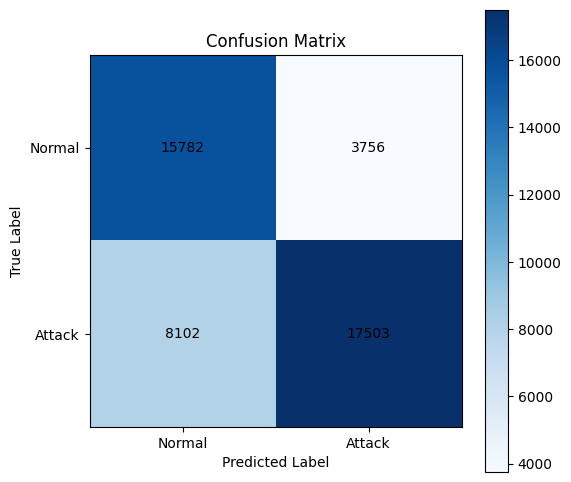

In [ ]:
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_tensor.cpu(),
    pred.cpu()
)
plt.figure(figsize=(6,6))
plt.imshow(cm, cmap = 'Blues')
plt.title("Confusion Matrix")
plt.colorbar()

classes = ['Normal', 'Attack']

tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Tambahkan angka pada matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha='center',
            va='center'
        )
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [ ]:
torch.save(
    model.state_dict(),
    "gcn_ddos_detector.pth"
)

print("Model saved")

Model saved


In [ ]:
from google.colab import files

files.download("gcn_ddos_detector.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# CICID2018

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv

In [ ]:
df = pd.read_csv("cic.csv")

print(df.shape)

df.head()

(1048575, 80)


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign


In [ ]:
# Rapikan nama kolom
df.columns = df.columns.str.strip()

# Replace infinity
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop missing value
df.dropna(inplace=True)

print(df.shape)

(1044751, 80)


In [ ]:
print(df['Label'].value_counts())

Label
Benign            663808
FTP-BruteForce    193354
SSH-Bruteforce    187589
Name: count, dtype: int64


In [ ]:
df['Label'] = df['Label'].apply(
    lambda x: 0 if x == 'Benign' else 1
)

print(df['Label'].value_counts())

Label
0    663808
1    380943
Name: count, dtype: int64


In [ ]:
X = df.drop(columns=['Label'])

# Ambil hanya numerik
X = X.select_dtypes(include=[np.number])

y = df['Label']

print(X.shape)

(1044751, 78)


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
x_train = torch.tensor(
    X_train,
    dtype=torch.float
)

y_train = torch.tensor(
    y_train.values,
    dtype=torch.long
)

In [ ]:
edge_index = []

for i in range(len(X_train)-1):

    edge_index.append([i, i+1])
    edge_index.append([i+1, i])

edge_index = torch.tensor(
    edge_index,
    dtype=torch.long
).t().contiguous()

print(edge_index.shape)

torch.Size([2, 1671598])


In [ ]:
train_data = Data(
    x=x_train,
    edge_index=edge_index,
    y=y_train
)

print(train_data)

Data(x=[835800, 78], edge_index=[2, 1671598], y=[835800])


In [ ]:
class GCNModel(torch.nn.Module):

    def __init__(self, input_dim):

        super(GCNModel, self).__init__()

        self.gcn1 = GCNConv(input_dim, 64)

        self.gat1 = GATConv(64, 64)

        self.fc = torch.nn.Linear(64, 2)

        self.dropout = torch.nn.Dropout(0.3)

    def forward(self, data):

        x, edge_index = data.x, data.edge_index

        x = self.gcn1(x, edge_index)
        x = F.relu(x)

        x = self.gat1(x, edge_index)
        x = F.relu(x)

        x = self.dropout(x)

        x = self.fc(x)

        return F.log_softmax(x, dim=1)

In [ ]:
model = GCNModel(
    input_dim=X_train.shape[1]
)

print(model)

GCNModel(
  (gcn1): GCNConv(78, 64)
  (gat1): GATConv(64, 64, heads=1)
  (fc): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [ ]:
class_counts = np.bincount(y_train.numpy())

weights = 1. / class_counts

weights = torch.tensor(
    weights,
    dtype=torch.float
)

criterion = torch.nn.NLLLoss(
    weight=weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
epochs = 20

model.train()

for epoch in range(epochs):
    optimizer.zero_grad()
    out = model(train_data)
    loss = criterion(out, train_data.y)
    loss.backward()
    optimizer.step()
    pred = out.argmax(dim=1)
    acc = (
        (pred == train_data.y)
        .sum()
        .item()
        / len(train_data.y)
    )

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {loss.item():.4f} | "
        f"Accuracy: {acc:.4f}"
    )

Epoch 1 | Loss: 0.6964 | Accuracy: 0.5088
Epoch 2 | Loss: 0.6884 | Accuracy: 0.5642
Epoch 3 | Loss: 0.6811 | Accuracy: 0.6095
Epoch 4 | Loss: 0.6740 | Accuracy: 0.6439
Epoch 5 | Loss: 0.6672 | Accuracy: 0.6681
Epoch 6 | Loss: 0.6605 | Accuracy: 0.6858
Epoch 7 | Loss: 0.6540 | Accuracy: 0.6966
Epoch 8 | Loss: 0.6474 | Accuracy: 0.7064
Epoch 9 | Loss: 0.6407 | Accuracy: 0.7118
Epoch 10 | Loss: 0.6340 | Accuracy: 0.7164
Epoch 11 | Loss: 0.6273 | Accuracy: 0.7193
Epoch 12 | Loss: 0.6205 | Accuracy: 0.7227
Epoch 13 | Loss: 0.6139 | Accuracy: 0.7243
Epoch 14 | Loss: 0.6071 | Accuracy: 0.7260
Epoch 15 | Loss: 0.6000 | Accuracy: 0.7283
Epoch 16 | Loss: 0.5933 | Accuracy: 0.7298
Epoch 17 | Loss: 0.5867 | Accuracy: 0.7314
Epoch 18 | Loss: 0.5799 | Accuracy: 0.7328
Epoch 19 | Loss: 0.5733 | Accuracy: 0.7350
Epoch 20 | Loss: 0.5665 | Accuracy: 0.7367


In [ ]:
x_test = torch.tensor(
    X_test,
    dtype=torch.float
)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.long
)

edge_test = []

for i in range(len(X_test)-1):

    edge_test.append([i, i+1])
    edge_test.append([i+1, i])

edge_test = torch.tensor(
    edge_test,
    dtype=torch.long
).t().contiguous()

test_data = Data(
    x=x_test,
    edge_index=edge_test,
    y=y_test_tensor
)

In [ ]:
model.eval()

with torch.no_grad():

    output = model(test_data)

    pred = output.argmax(dim=1)

print(
    classification_report(
        y_test_tensor.cpu(),
        pred.cpu()
    )
)

              precision    recall  f1-score   support

           0       0.82      0.76      0.79    132762
           1       0.63      0.71      0.67     76189

    accuracy                           0.74    208951
   macro avg       0.72      0.73      0.73    208951
weighted avg       0.75      0.74      0.74    208951



Text(0, 0.5, 'True Label')

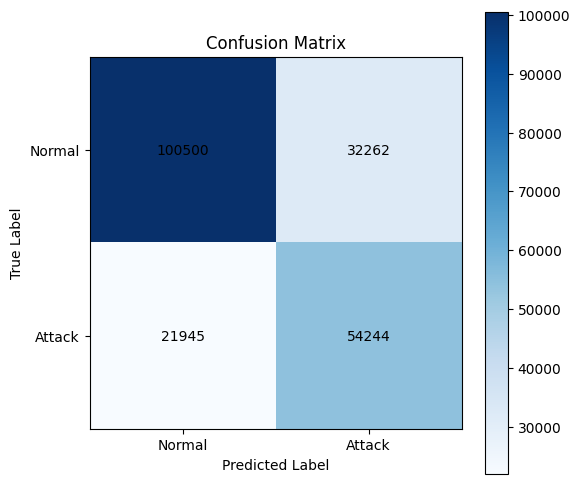

In [ ]:
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test_tensor.cpu(),
    pred.cpu()
)
plt.figure(figsize=(6,6))
plt.imshow(cm, cmap = 'Blues')
plt.title("Confusion Matrix")
plt.colorbar()

classes = ['Normal', 'Attack']

tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Tambahkan angka pada matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha='center',
            va='center'
        )
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

In [ ]:
torch.save(
    model.state_dict(),
    "gcn_ids_cicid2018_model.pth"
)

print("Model Saved")

Model Saved


In [ ]:
from google.colab import files

files.download("gcn_ids_cicid2018_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# UNSW-NB15

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv

In [ ]:
train_df = pd.read_csv(
    "UNSW_NB15_training-set.csv"
)

test_df = pd.read_csv(
    "UNSW_NB15_testing-set.csv"
)

print(train_df.shape)
print(test_df.shape)

train_df.head()

(175341, 45)
(82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [ ]:
# Rapikan nama kolom
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

# Replace infinity
train_df.replace([np.inf, -np.inf], np.nan, inplace=True)
test_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop missing value
train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

In [ ]:
categorical_cols = [
    'proto',
    'service',
    'state'
]

encoder = LabelEncoder()

for col in categorical_cols:
    # Convert columns to string type to ensure uniform input for LabelEncoder
    train_df[col] = train_df[col].astype(str)
    test_df[col] = test_df[col].astype(str)

    # Combine unique values from both train and test to fit the encoder.
    # This ensures that the encoder learns all possible categories from both datasets.
    all_unique_values = pd.concat([train_df[col], test_df[col]], axis=0).unique()
    encoder.fit(all_unique_values)

    train_df[col] = encoder.transform(
        train_df[col]
    )

    test_df[col] = encoder.transform(
        test_df[col]
    )

In [ ]:
X_train = train_df.drop(
    columns=['label', 'attack_cat']
)

y_train = train_df['label']

X_test = test_df.drop(
    columns=['label', 'attack_cat']
)

y_test = test_df['label']

In [ ]:
X_train = X_train.select_dtypes(
    include=[np.number]
)

X_test = X_test.select_dtypes(
    include=[np.number]
)

print(X_train.shape)

(175341, 43)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
x_train = torch.tensor(
    X_train,
    dtype=torch.float
)

y_train = torch.tensor(
    y_train.values,
    dtype=torch.long
)

x_test = torch.tensor(
    X_test,
    dtype=torch.float
)

y_test = torch.tensor(
    y_test.values,
    dtype=torch.long
)

In [ ]:
edge_index_train = []

for i in range(len(X_train)-1):

    edge_index_train.append([i, i+1])
    edge_index_train.append([i+1, i])

edge_index_train = torch.tensor(
    edge_index_train,
    dtype=torch.long
).t().contiguous()

print(edge_index_train.shape)

torch.Size([2, 350680])


In [ ]:
train_data = Data(
    x=x_train,
    edge_index=edge_index_train,
    y=y_train
)

print(train_data)

Data(x=[175341, 43], edge_index=[2, 350680], y=[175341])


In [ ]:
class GCN_IDS(torch.nn.Module):

    def __init__(self, input_dim):

        super(GCN_IDS, self).__init__()

        # GCN Layer
        self.gcn1 = GCNConv(input_dim, 64)

        # Attention Layer
        self.gat1 = GATConv(64, 64)

        # Fully Connected
        self.fc = torch.nn.Linear(64, 2)

        self.dropout = torch.nn.Dropout(0.3)

    def forward(self, data):

        x, edge_index = data.x, data.edge_index

        x = self.gcn1(x, edge_index)
        x = F.relu(x)

        x = self.gat1(x, edge_index)
        x = F.relu(x)

        x = self.dropout(x)

        x = self.fc(x)

        return F.log_softmax(x, dim=1)

In [ ]:
model = GCN_IDS(
    input_dim=X_train.shape[1]
)

print(model)

GCN_IDS(
  (gcn1): GCNConv(43, 64)
  (gat1): GATConv(64, 64, heads=1)
  (fc): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [ ]:
class_counts = np.bincount(
    y_train.numpy()
)

weights = 1. / class_counts

weights = torch.tensor(
    weights,
    dtype=torch.float
)

criterion = torch.nn.NLLLoss(
    weight=weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
epochs = 20

model.train()

for epoch in range(epochs):
    optimizer.zero_grad()
    output = model(train_data)
    loss = criterion(
        output,
        train_data.y
    )
    loss.backward()
    optimizer.step()
    pred = output.argmax(dim=1)
    acc = (
        (pred == train_data.y)
        .sum()
        .item()
        / len(train_data.y)
    )

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {loss.item():.4f} | "
        f"Accuracy: {acc:.4f}"
    )

Epoch 1 | Loss: 0.7672 | Accuracy: 0.5007
Epoch 2 | Loss: 0.7433 | Accuracy: 0.5416
Epoch 3 | Loss: 0.7202 | Accuracy: 0.5835
Epoch 4 | Loss: 0.6981 | Accuracy: 0.6265
Epoch 5 | Loss: 0.6777 | Accuracy: 0.6662
Epoch 6 | Loss: 0.6580 | Accuracy: 0.7068
Epoch 7 | Loss: 0.6391 | Accuracy: 0.7444
Epoch 8 | Loss: 0.6216 | Accuracy: 0.7737
Epoch 9 | Loss: 0.6048 | Accuracy: 0.7953
Epoch 10 | Loss: 0.5887 | Accuracy: 0.8088
Epoch 11 | Loss: 0.5733 | Accuracy: 0.8179
Epoch 12 | Loss: 0.5585 | Accuracy: 0.8225
Epoch 13 | Loss: 0.5437 | Accuracy: 0.8244
Epoch 14 | Loss: 0.5294 | Accuracy: 0.8255
Epoch 15 | Loss: 0.5155 | Accuracy: 0.8269
Epoch 16 | Loss: 0.5015 | Accuracy: 0.8289
Epoch 17 | Loss: 0.4877 | Accuracy: 0.8302
Epoch 18 | Loss: 0.4744 | Accuracy: 0.8325
Epoch 19 | Loss: 0.4611 | Accuracy: 0.8351
Epoch 20 | Loss: 0.4486 | Accuracy: 0.8369


In [ ]:
edge_index_test = []

for i in range(len(X_test)-1):

    edge_index_test.append([i, i+1])
    edge_index_test.append([i+1, i])

edge_index_test = torch.tensor(
    edge_index_test,
    dtype=torch.long
).t().contiguous()

test_data = Data(
    x=x_test,
    edge_index=edge_index_test,
    y=y_test
)

In [ ]:
model.eval()

with torch.no_grad():

    output = model(test_data)

    pred = output.argmax(dim=1)

print(
    classification_report(
        y_test.cpu(),
        pred.cpu()
    )
)

              precision    recall  f1-score   support

           0       0.68      0.78      0.73     37000
           1       0.80      0.70      0.74     45332

    accuracy                           0.74     82332
   macro avg       0.74      0.74      0.74     82332
weighted avg       0.74      0.74      0.74     82332



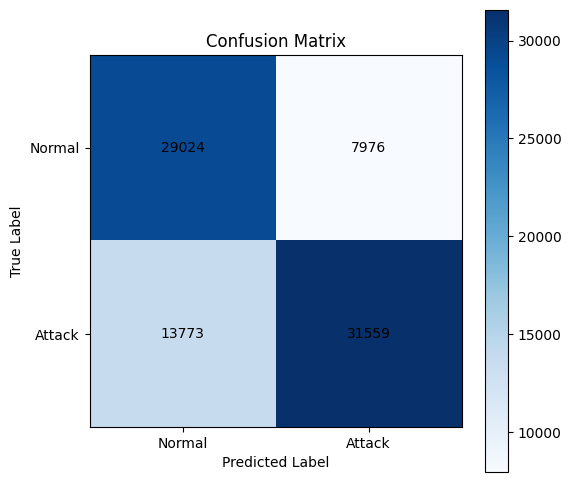

In [ ]:
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test.cpu(),
    pred.cpu()
)
plt.figure(figsize=(6,6))
plt.imshow(cm, cmap = 'Blues')
plt.title("Confusion Matrix")
plt.colorbar()

classes = ['Normal', 'Attack']

tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Tambahkan angka pada matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha='center',
            va='center'
        )
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
torch.save(
    model.state_dict(),
    "unsw_gcn_model.pth"
)

print("Model Saved")

Model Saved


In [ ]:
from google.colab import files

files.download(
    "unsw_gcn_model.pth"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Comparsion

In [ ]:
import pandas as pd
import numpy as np

import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from torch_geometric.data import Data
from torch_geometric.nn import (
    GCNConv,
    GATConv
)

In [ ]:
class GCN_IDS(torch.nn.Module):

    def __init__(self, input_dim):

        super(GCN_IDS, self).__init__()

        self.gcn1 = GCNConv(input_dim, 64)

        self.gat1 = GATConv(64, 64)

        self.fc = torch.nn.Linear(64, 2)

        self.dropout = torch.nn.Dropout(0.3)

    def forward(self, data):

        x, edge_index = data.x, data.edge_index

        x = self.gcn1(x, edge_index)
        x = F.relu(x)

        x = self.gat1(x, edge_index)
        x = F.relu(x)

        x = self.dropout(x)

        x = self.fc(x)

        return F.log_softmax(x, dim=1)

In [ ]:
def evaluate_model(y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)

    prec = precision_score(y_true, y_pred)

    rec = recall_score(y_true, y_pred)

    f1 = f1_score(y_true, y_pred)

    return [acc, prec, rec, f1]

In [ ]:
def prepare_graph_data(df, label_column):

    df.columns = df.columns.str.strip()

    df.replace(
        [np.inf, -np.inf],
        np.nan,
        inplace=True
    )

    df.dropna(inplace=True)

    # Encode categorical
    for col in df.columns:

        if df[col].dtype == 'object':

            if col != label_column:

                encoder = LabelEncoder()

                df[col] = encoder.fit_transform(
                    df[col].astype(str)
                )

    # Binary label
    df[label_column] = df[label_column].apply(
        lambda x: 0 if str(x).lower() in ['benign', 'normal', '0'] else 1
    )

    X = df.drop(columns=[label_column])

    X = X.select_dtypes(include=[np.number])

    y = df[label_column]

    scaler = StandardScaler()

    X = scaler.fit_transform(X)

    x_tensor = torch.tensor(
        X,
        dtype=torch.float
    )

    y_tensor = torch.tensor(
        y.values,
        dtype=torch.long
    )

    # Build graph edge
    edge_index = []

    for i in range(len(X)-1):

        edge_index.append([i, i+1])
        edge_index.append([i+1, i])

    edge_index = torch.tensor(
        edge_index,
        dtype=torch.long
    ).t().contiguous()

    data = Data(
        x=x_tensor,
        edge_index=edge_index,
        y=y_tensor
    )

    return data

In [ ]:
cicids_df = pd.read_csv(
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
)

cicids_data = prepare_graph_data(
    cicids_df,
    'Label'
)

In [ ]:
cic_df = pd.read_csv("cic.csv")
cic_df = cic_df.drop(columns=['Timestamp']) # Drop the 'Timestamp' column

cic_data = prepare_graph_data(
    cic_df,
    'Label'
)

In [ ]:
unsw_df = pd.read_csv(
    "UNSW_NB15_testing-set.csv"
)
unsw_df = unsw_df.drop(columns=['attack_cat']) # Drop the 'attack_cat' column

unsw_data = prepare_graph_data(
    unsw_df,
    'label'
)

In [ ]:
model1 = GCN_IDS(
    input_dim=cicids_data.num_features
)

model1.load_state_dict(
    torch.load("gcn_ddos_detector.pth")
)

model1.eval()

GCN_IDS(
  (gcn1): GCNConv(78, 64)
  (gat1): GATConv(64, 64, heads=1)
  (fc): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

In [ ]:
model2 = GCN_IDS(
    input_dim=cic_data.num_features
)

model2.load_state_dict(
    torch.load("gcn_ids_cicid2018_model.pth")
)

model2.eval()

GCN_IDS(
  (gcn1): GCNConv(78, 64)
  (gat1): GATConv(64, 64, heads=1)
  (fc): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

In [ ]:
model3 = GCN_IDS(
    input_dim=unsw_data.num_features
)

model3.load_state_dict(
    torch.load("unsw_gcn_model.pth")
)

model3.eval()

GCN_IDS(
  (gcn1): GCNConv(43, 64)
  (gat1): GATConv(64, 64, heads=1)
  (fc): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

In [ ]:
with torch.no_grad():

    pred1 = model1(cicids_data).argmax(dim=1)

    pred2 = model2(cic_data).argmax(dim=1)

    pred3 = model3(unsw_data).argmax(dim=1)

In [ ]:
metrics1 = evaluate_model(
    cicids_data.y.cpu(),
    pred1.cpu()
)

metrics2 = evaluate_model(
    cic_data.y.cpu(),
    pred2.cpu()
)

metrics3 = evaluate_model(
    unsw_data.y.cpu(),
    pred3.cpu()
)

# Results

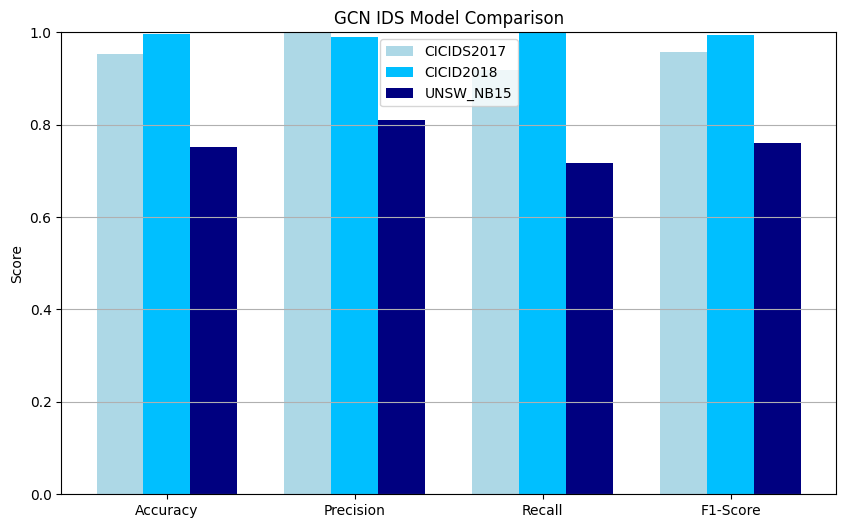

In [ ]:
models = [
    'CICIDS2017',
    'CICID2018',
    'UNSW_NB15'
]

metric_names = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
]

x = np.arange(len(metric_names))
width = 0.25
plt.figure(figsize=(10,6))

colors = [
    'lightblue',
    'deepskyblue',
    'navy'
]

plt.bar(
    x - width,
    metrics1,
    width,
    label=models[0],
    color=colors[0]
)

plt.bar(
    x,
    metrics2,
    width,
    label=models[1],
    color=colors[1]
)

plt.bar(
    x + width,
    metrics3,
    width,
    label=models[2],
    color=colors[2]
)

plt.xticks(x, metric_names)
plt.ylim(0,1)
plt.ylabel('Score')
plt.title('GCN IDS Model Comparison')
plt.legend()
plt.grid(axis='y')
plt.show()

In [ ]:
metric_names = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
]

# CICIDS2017
print("===== CICIDS2017 =====")

for name, value in zip(metric_names, metrics1):

    print(f"{name}: {value:.4f}")

print()


# cic.csv
print("===== CICID2018 =====")

for name, value in zip(metric_names, metrics2):

    print(f"{name}: {value:.4f}")

print()


# UNSW_NB15
print("===== UNSW_NB15 =====")

for name, value in zip(metric_names, metrics3):

    print(f"{name}: {value:.4f}")

===== CICIDS2017 =====
Accuracy: 0.9539
Precision: 0.9996
Recall: 0.9191
F1-Score: 0.9577

===== CICID2018 =====
Accuracy: 0.9959
Precision: 0.9891
Recall: 1.0000
F1-Score: 0.9945

===== UNSW_NB15 =====
Accuracy: 0.7515
Precision: 0.8098
Recall: 0.7172
F1-Score: 0.7607


Berdasarkan hasil pengujian model **Graph Convolutional Network (GCN)** pada tiga dataset IDS yang berbeda, dapat disimpulkan bahwa GCN mampu mendeteksi anomali jaringan dengan performa yang sangat baik pada dataset yang memiliki pola komunikasi yang jelas dan representasi graf yang kuat. Namun, performanya dapat menurun pada dataset yang memiliki karakteristik serangan yang lebih kompleks atau hubungan antar-node yang kurang terwakili oleh konstruksi graf yang digunakan.

### Hasil Pengujian

| Dataset    | Accuracy | Precision | Recall  | F1-Score |
| ---------- | -------- | --------- | ------- | -------- |
| CICIDS2017 | 95.39%   | 99.96%    | 91.91%  | 95.77%   |
| CICIDS2018 | 99.59%   | 98.91%    | 100.00% | 99.45%   |
| UNSW-NB15  | 75.15%   | 80.98%    | 71.72%  | 76.07%   |

### Analisis Hasil

#### 1. Performa pada CICIDS2017

Model GCN memperoleh **Accuracy sebesar 95.39%** dan **F1-Score sebesar 95.77%**, menunjukkan kemampuan yang sangat baik dalam membedakan trafik normal dan serangan. Nilai **Precision yang hampir sempurna (99.96%)** mengindikasikan bahwa hampir seluruh trafik yang diklasifikasikan sebagai serangan memang benar merupakan serangan. Namun, nilai Recall sebesar 91.91% menunjukkan masih terdapat sebagian kecil serangan yang tidak terdeteksi.

#### 2. Performa pada CICIDS2018

Dataset CICIDS2018 menghasilkan performa terbaik dengan **Accuracy 99.59%** dan **F1-Score 99.45%**. Nilai Recall mencapai **100%**, yang berarti seluruh serangan berhasil terdeteksi oleh model. Hasil ini menunjukkan bahwa GCN sangat efektif dalam memanfaatkan hubungan antar-flow pada dataset yang memiliki pola serangan yang lebih terstruktur dan representatif.

#### 3. Performa pada UNSW-NB15

Pada dataset UNSW-NB15, performa model menurun dengan **Accuracy 75.15%** dan **F1-Score 76.07%**. Penurunan ini dapat disebabkan oleh beberapa faktor:

* Karakteristik serangan pada UNSW-NB15 lebih beragam dan kompleks.
* Distribusi data lebih heterogen dibandingkan CICIDS.
* Struktur graph yang dibangun secara sederhana (misalnya sequential edge) belum mampu merepresentasikan hubungan komunikasi sebenarnya.
* Banyak fitur kategorikal yang harus diencoding sehingga informasi relasional berkurang.

Meskipun demikian, nilai Precision sebesar 80.98% menunjukkan bahwa model masih cukup baik dalam mengidentifikasi trafik serangan.

### Kesimpulan Metode GCN
Metode **Graph Convolutional Network (GCN)** terbukti efektif untuk sistem deteksi intrusi berbasis jaringan karena mampu memanfaatkan informasi topologi dan hubungan antar entitas jaringan yang tidak dapat ditangkap oleh metode machine learning konvensional. Berdasarkan hasil eksperimen:

* GCN memberikan performa sangat tinggi pada dataset **CICIDS2017** dan **CICIDS2018**, dengan nilai Accuracy di atas 95%.
* Dataset **CICIDS2018** menjadi dataset dengan performa terbaik karena mencapai Accuracy hampir 100%.
* Performa pada **UNSW-NB15** masih cukup baik, namun menunjukkan bahwa kualitas konstruksi graf sangat mempengaruhi keberhasilan model.
* GCN lebih unggul ketika hubungan antar node dalam jaringan dapat direpresentasikan dengan baik pada graph.

### Saran Pengembangan

Untuk meningkatkan performa terutama pada UNSW-NB15, beberapa pengembangan yang dapat dilakukan adalah:

1. Menggunakan **Graph Attention Network (GAT)** yang lebih adaptif terhadap hubungan antar node.
2. Membangun graph berdasarkan:
   * Source IP
   * Destination IP
   * Port
   * Similarity antar flow (KNN Graph)

   dibandingkan hanya menggunakan sequential edge.
3. Menambahkan **LSTM/GRU** untuk menangkap informasi temporal sebagaimana dijelaskan dalam paper.
4. Menggunakan **Dynamic Graph Construction** agar perubahan pola trafik dari waktu ke waktu dapat dipelajari model.
5. Menambahkan teknik penanganan imbalance seperti **Focal Loss** atau **SMOTE**.

Secara keseluruhan, hasil pengujian menunjukkan bahwa **GCN merupakan metode yang sangat potensial untuk Intrusion Detection System (IDS)**, terutama pada dataset modern seperti CICIDS2017 dan CICIDS2018 yang memiliki struktur komunikasi jaringan yang dapat direpresentasikan secara efektif dalam bentuk graph.

| Dataset        | Characteristics                             |
| -------------- | ------------------------------------------- |
| **CICIDS2017** | Realistic benign and attack traffic         |
| **CICIDS2018** | Larger and more structured attack scenarios |
| **UNSW-NB15**  | Diverse and heterogeneous attacks           |
